# Final Individual Project

## Research Question
Does experiencing prolonged feelings of sadness or hopelessness increase the probability of current cigarette use among adolescents?

## Motivation
Adolescent smoking remains a major public health concern. Previous research suggests that emotional distress may influence risky health behaviors. This project investigates whether students who report sadness or hopelessness are more likely to be current cigarette users.

## Statistical Method
Linear Probability Model (OLS Regression)
$$Smoke\_recoded = \beta_0 + \beta_1(Sad\_recoded)$$

In [95]:
import os
import pandas as pd

file_path = os.path.join('..', 'data', 'raw', 'YRBS_2007.csv')
df = pd.read_csv(file_path)

if 'WhatIsYourSex' in df.columns:
    df = df.rename(columns={'WhatIsYourSex': 'Sex'})

df_clean = df[['SadOrHopeless', 'CurrentCigaretteUse', 'Sex']].copy()
print(f"Total loaded records: {len(df_clean)}")

Total loaded records: 14041


In [96]:
df_clean['Sad_recoded'] = df_clean['SadOrHopeless'].replace({1.0: 1, 2.0: 0})
df_clean['Smoke_recoded'] = df_clean['CurrentCigaretteUse'].replace({1.0: 0, 2.0: 1, 3.0: 1, 4.0: 1, 5.0: 1, 6.0: 1, 7.0: 1})

df_main = df_clean[df_clean['Sad_recoded'].isin([0, 1]) & df_clean['Smoke_recoded'].isin([0, 1])].copy()

print(f"Sad (Yes=1): {len(df_main[df_main['Sad_recoded'] == 1])}")
print(f"Sad (No=0): {len(df_main[df_main['Sad_recoded'] == 0])}")
print(f"Total Sample Size for Main Analysis: {len(df_main)}")

Sad (Yes=1): 3854
Sad (No=0): 9320
Total Sample Size for Main Analysis: 13174


In [97]:
os.makedirs('../data/processed/', exist_ok=True)
df_main.to_csv('../data/processed/cleaned_data.csv', index=False, encoding='utf-8')

# 02 Exploratory Data Analysis (EDA) and Group Summaries

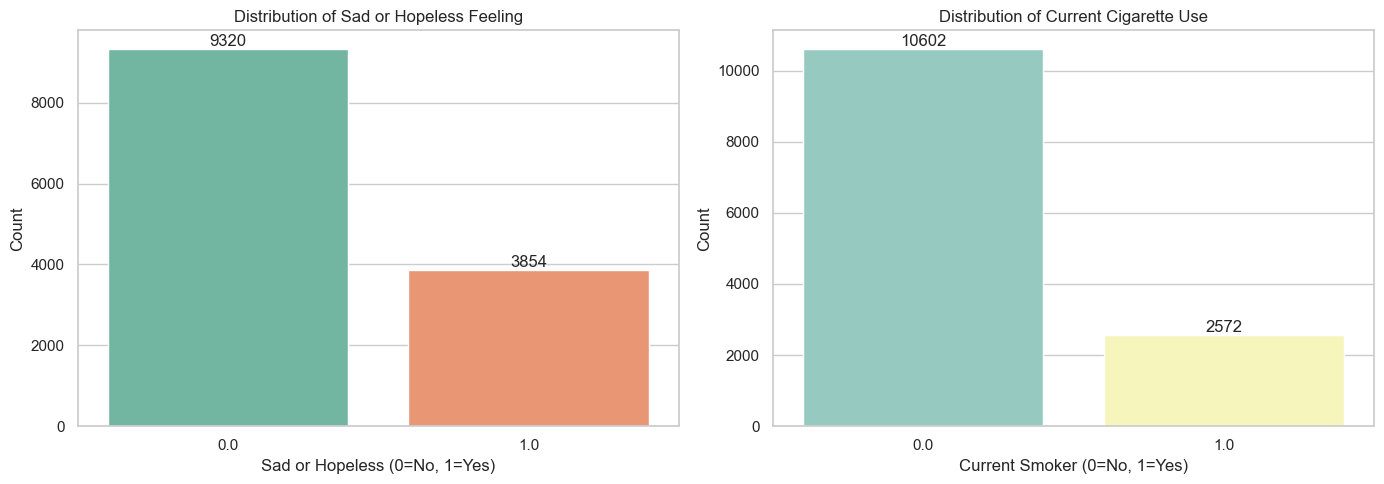

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(x='Sad_recoded', data=df_main, ax=axes[0], hue='Sad_recoded', palette="Set2", legend=False)
axes[0].set_title('Distribution of Sad or Hopeless Feeling')
axes[0].set_xlabel('Sad or Hopeless (0=No, 1=Yes)')
axes[0].set_ylabel('Count')

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

sns.countplot(x='Smoke_recoded', data=df_main, ax=axes[1], hue='Smoke_recoded', palette="Set3", legend=False)
axes[1].set_title('Distribution of Current Cigarette Use')
axes[1].set_xlabel('Current Smoker (0=No, 1=Yes)')
axes[1].set_ylabel('Count')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Interpretation of Basic Distributions
Most students did not report sadness or hopelessness. Most students were also non-smokers. The sample size is sufficiently large for statistical analysis.

In [99]:
group_summary = df_main.groupby('Sad_recoded')['Smoke_recoded'].agg(['count', 'mean']).reset_index()
group_summary['Sad_recoded'] = group_summary['Sad_recoded'].map({0: 'Not Sad', 1: 'Sad'})
group_summary.columns = ['Group', 'Sample Size (n)', 'Smoking Rate']

os.makedirs('../outputs/tables/', exist_ok=True)
group_summary.to_csv('../outputs/tables/group_summary.csv', index=False)

group_summary['Smoking Rate'] = group_summary['Smoking Rate'].map(lambda x: f"{x*100:.2f}%")
display(group_summary)

,Group,Sample Size (n),Smoking Rate
0,Not Sad,9320,16.18%
1,Sad,3854,27.61%


### Interpretation of Group Summaries
Students who reported sadness or hopelessness had a noticeably higher smoking prevalence.
* Smoking rate for Not Sad group: 16.18%
* Smoking rate for Sad group: 27.61%
* Observed Difference: 11.43 percentage points

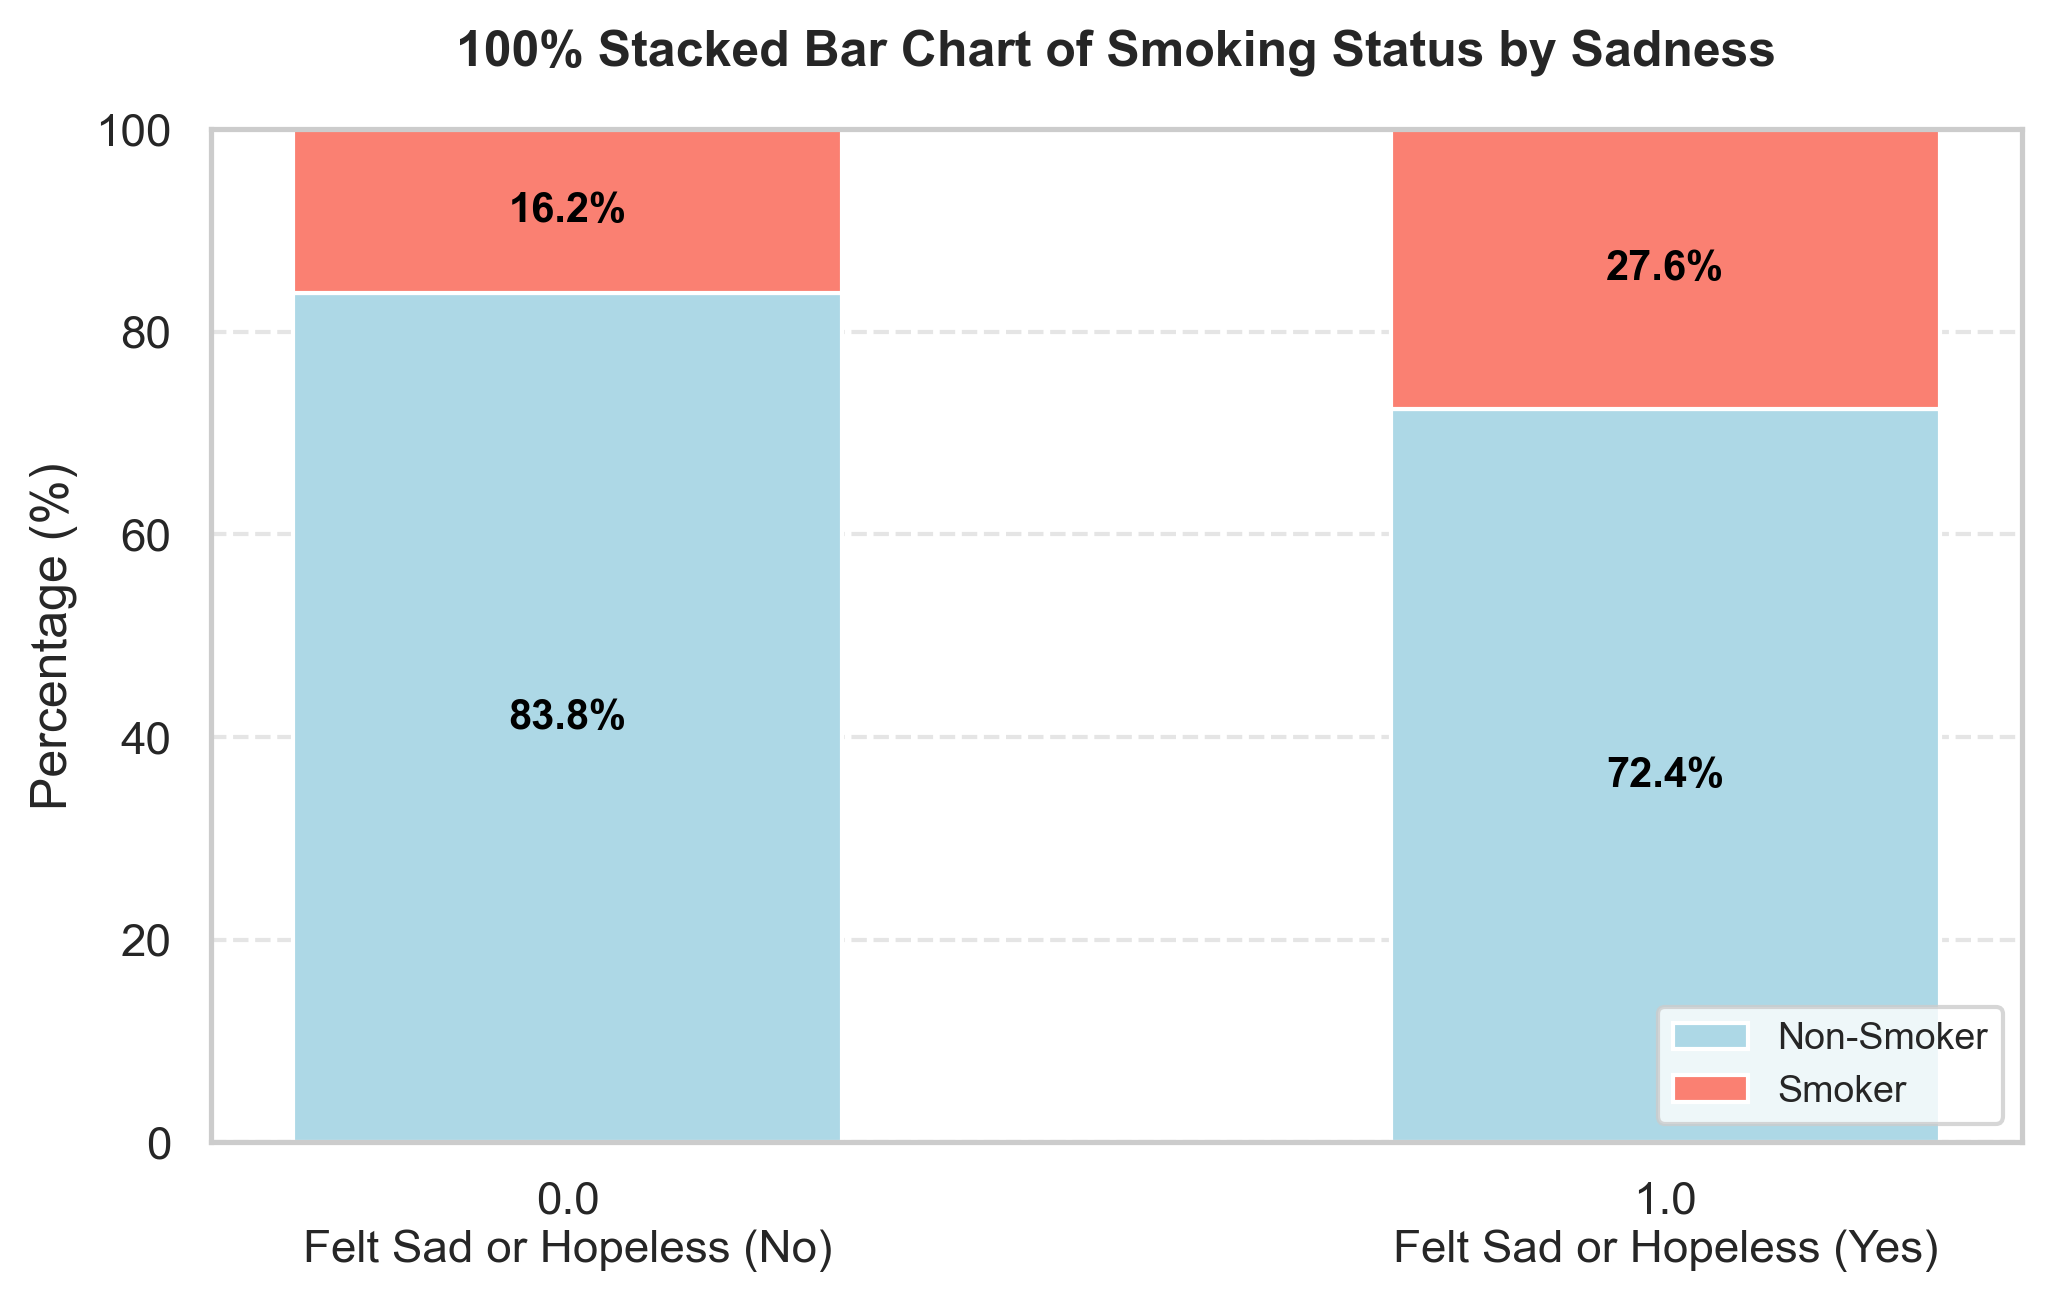

In [100]:
import matplotlib.pyplot as plt
import numpy as np

groups = ['0.0\nFelt Sad or Hopeless (No)', '1.0\nFelt Sad or Hopeless (Yes)']
non_smokers = [83.8197, 72.3923]
smokers = [16.1803, 27.6077]

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)
bars_non = ax.bar(groups, non_smokers, label='Non-Smoker', color='lightblue', width=0.5, edgecolor='white')
bars_smoke = ax.bar(groups, smokers, bottom=non_smokers, label='Smoker', color='salmon', width=0.5, edgecolor='white')

for bar in bars_non:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height/2, f'{height:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

for bar in bars_smoke:
    y_base = bar.get_y()
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y_base + height/2, f'{height:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=9, markerscale=0.7, frameon=True)
ax.set_title('100% Stacked Bar Chart of Smoking Status by Sadness', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()

os.makedirs('../outputs/figures/', exist_ok=True)
plt.savefig('../outputs/figures/stacked_bar_perfect.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of Stacked Bar Chart
The stacked bar chart shows the composition of smokers and non-smokers within each emotional-health group. Among students who did not feel sad or hopeless, only 16.2% were smokers. Among students who felt sad or hopeless, 27.6% were smokers. The visual difference suggests a positive association between emotional distress and smoking behavior.

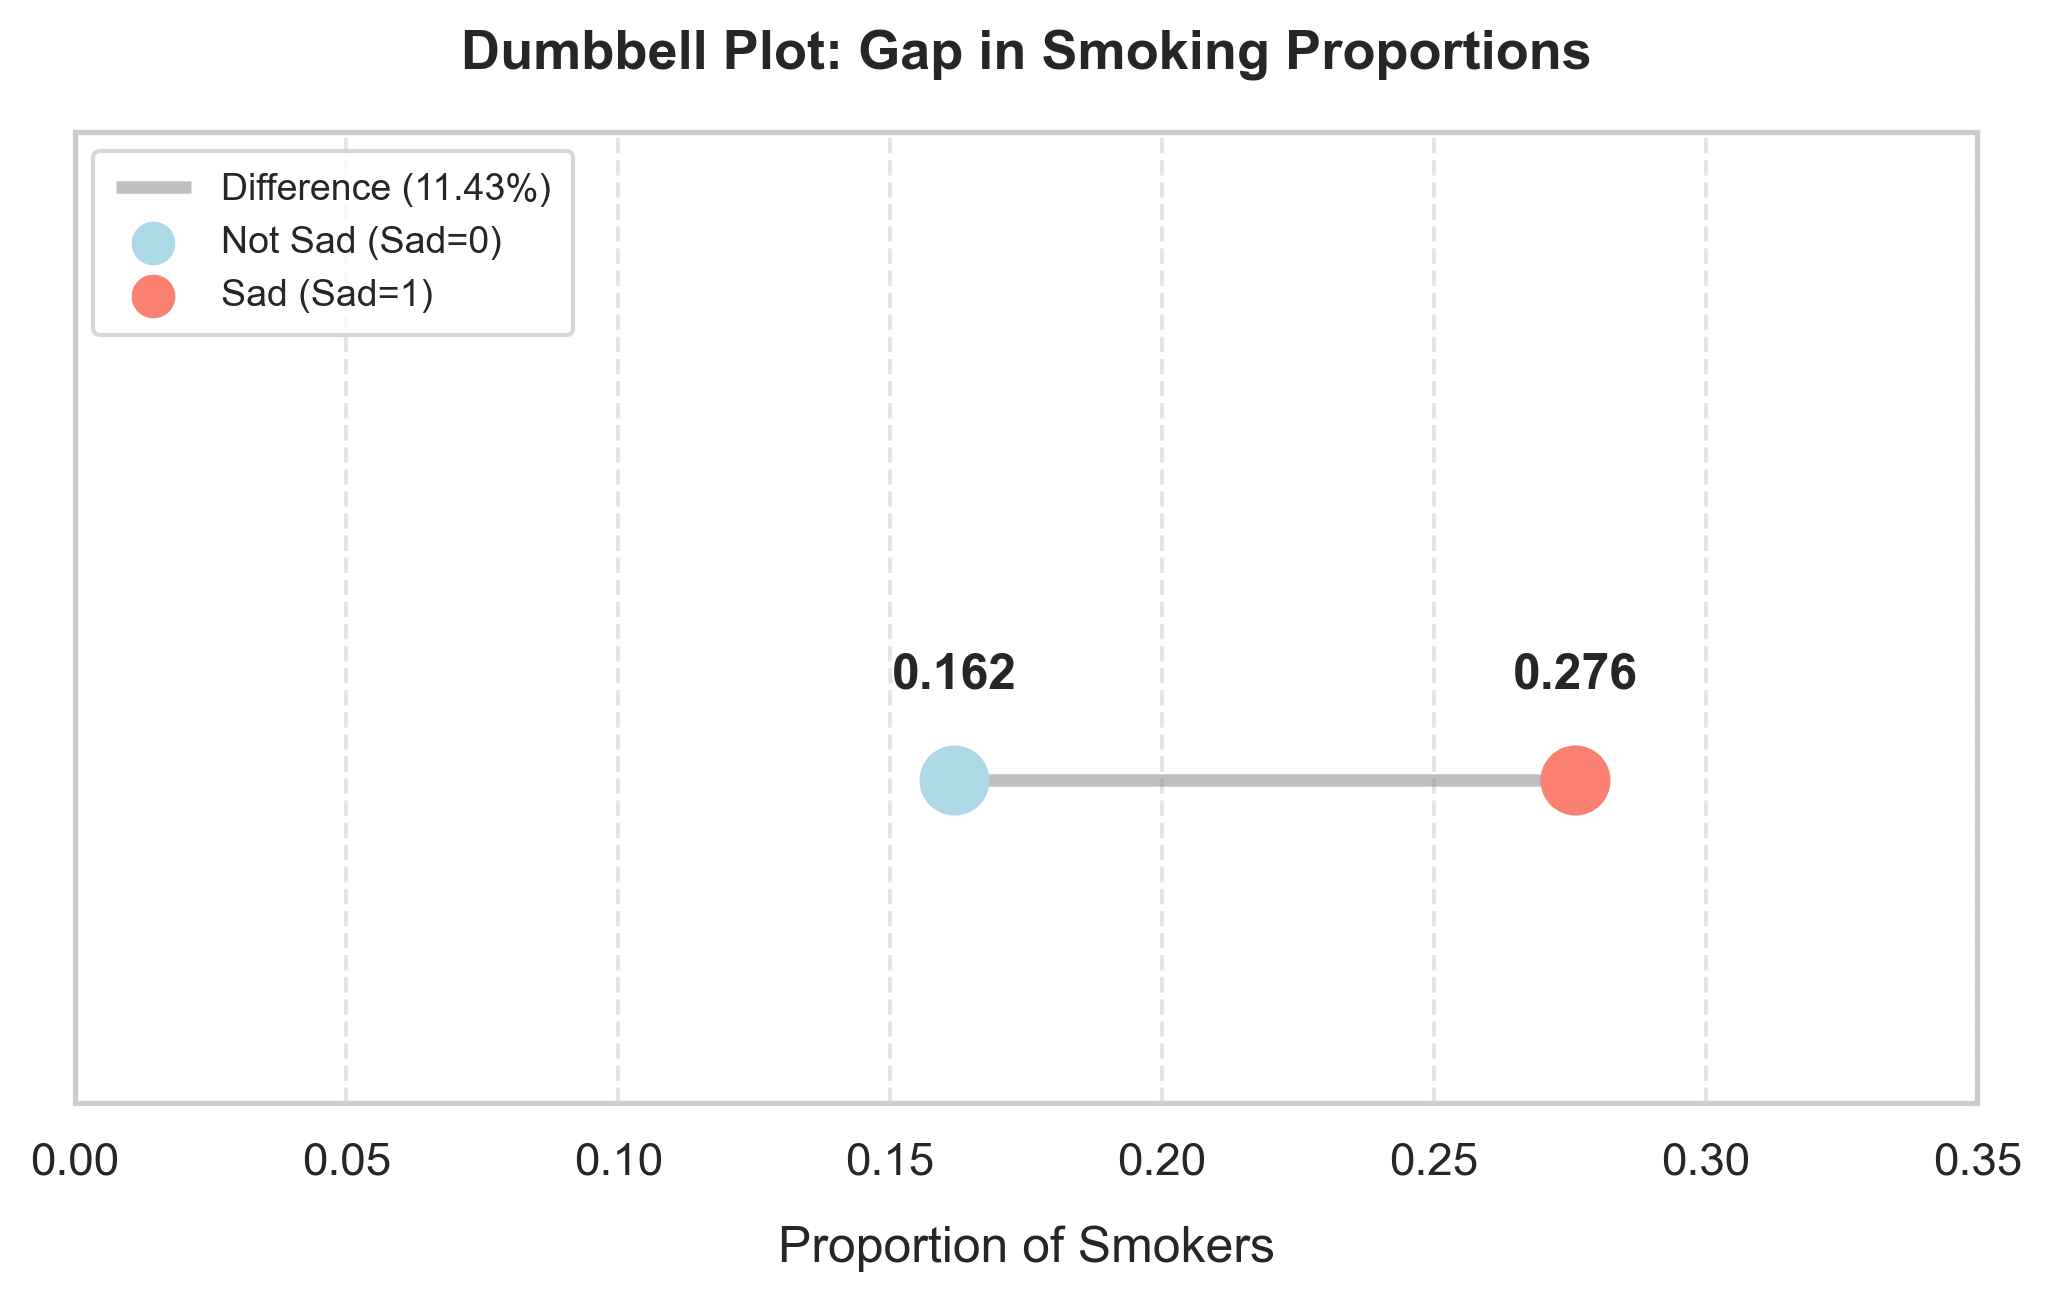

In [101]:
p_0 = 0.161803
p_1 = 0.276077

plt.figure(figsize=(7, 4.5), dpi=300)
plt.hlines(y=1, xmin=p_0, xmax=p_1, color='grey', alpha=0.5, linewidth=3, label='Difference (11.43%)')
plt.scatter(p_0, 1, color='lightblue', s=250, zorder=5, label='Not Sad (Sad=0)')
plt.scatter(p_1, 1, color='salmon', s=250, zorder=5, label='Sad (Sad=1)')

plt.text(p_0, 1.05, f'{p_0:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.text(p_1, 1.05, f'{p_1:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlim(0.00, 0.35)
plt.xticks([0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35])
plt.xlabel('Proportion of Smokers', fontsize=12, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.5, zorder=1)
plt.yticks([])
plt.ylim(0.8, 1.4)
plt.legend(loc='upper left', fontsize=9, markerscale=0.6, frameon=True, borderpad=0.6)
plt.title('Dumbbell Plot: Gap in Smoking Proportions', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

os.makedirs('../outputs/figures/', exist_ok=True)
plt.savefig('../outputs/figures/dumbbell_plot_perfect.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of Dumbbell Plot
The Dumbbell Plot isolates the smoking proportions of the two groups. The horizontal distance between the two points represents the observed effect size. Students reporting sadness or hopelessness exhibit an 11.43 percentage-point higher smoking prevalence.

Relative Risk = 1.71


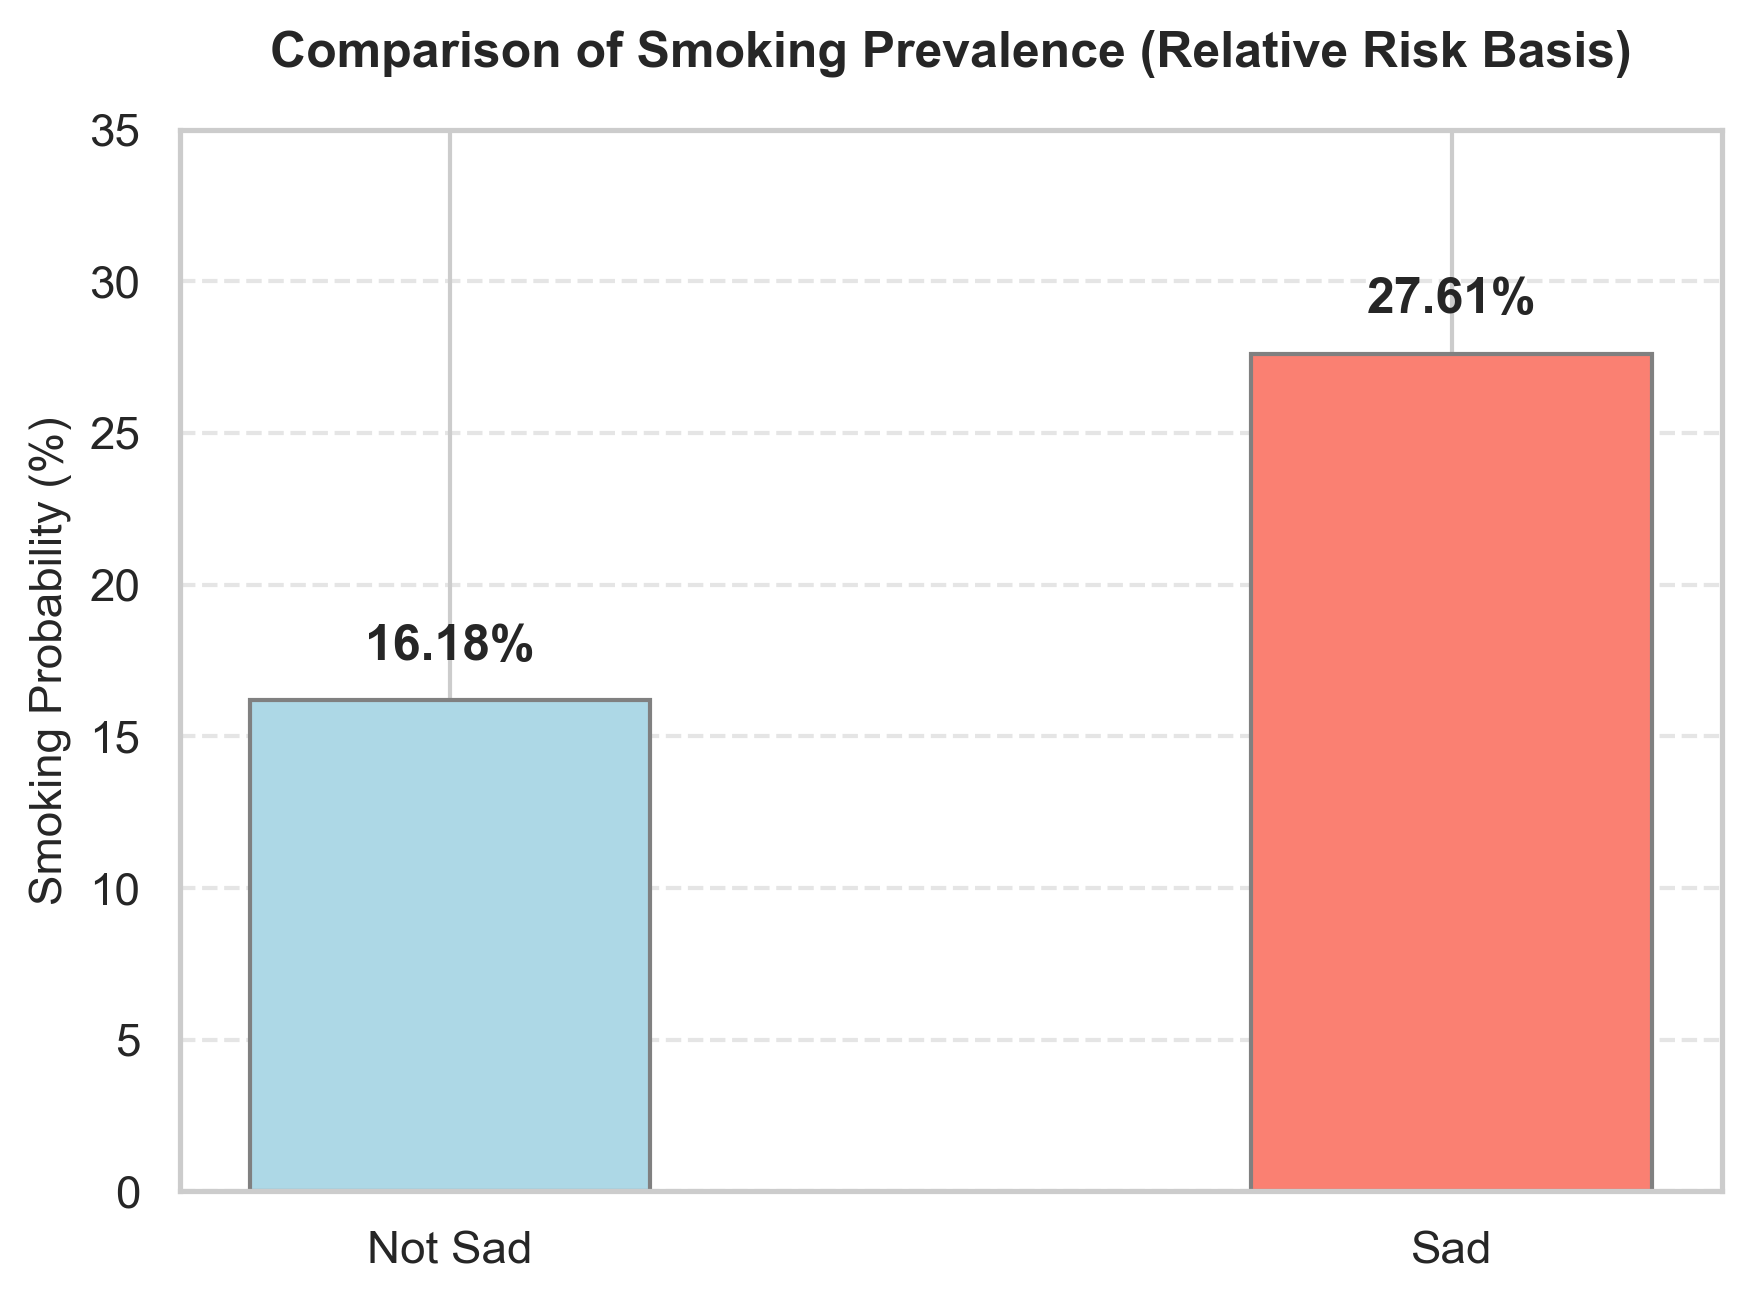

In [102]:
risk_no = df_main[df_main['Sad_recoded'] == 0]['Smoke_recoded'].mean()
risk_yes = df_main[df_main['Sad_recoded'] == 1]['Smoke_recoded'].mean()
relative_risk = risk_yes / risk_no

print(f"Relative Risk = {relative_risk:.2f}")

plt.figure(figsize=(6, 4.5), dpi=300)
bars = plt.bar(['Not Sad', 'Sad'], [risk_no * 100, risk_yes * 100], color=['lightblue', 'salmon'], width=0.4, edgecolor='grey')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.ylabel('Smoking Probability (%)', fontsize=11)
plt.title('Comparison of Smoking Prevalence (Relative Risk Basis)', fontsize=12, fontweight='bold', pad=15)
plt.ylim(0, 35)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

os.makedirs('../outputs/figures/', exist_ok=True)
plt.savefig('../outputs/figures/relative_risk_bar.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of Relative Risk Analysis
The relative risk of 1.71 indicates that the smoking prevalence in the sad or hopeless group was approximately 1.71 times that of the non-sad group. This graphical support visually illustrates the risk contrast between the two student cohorts.

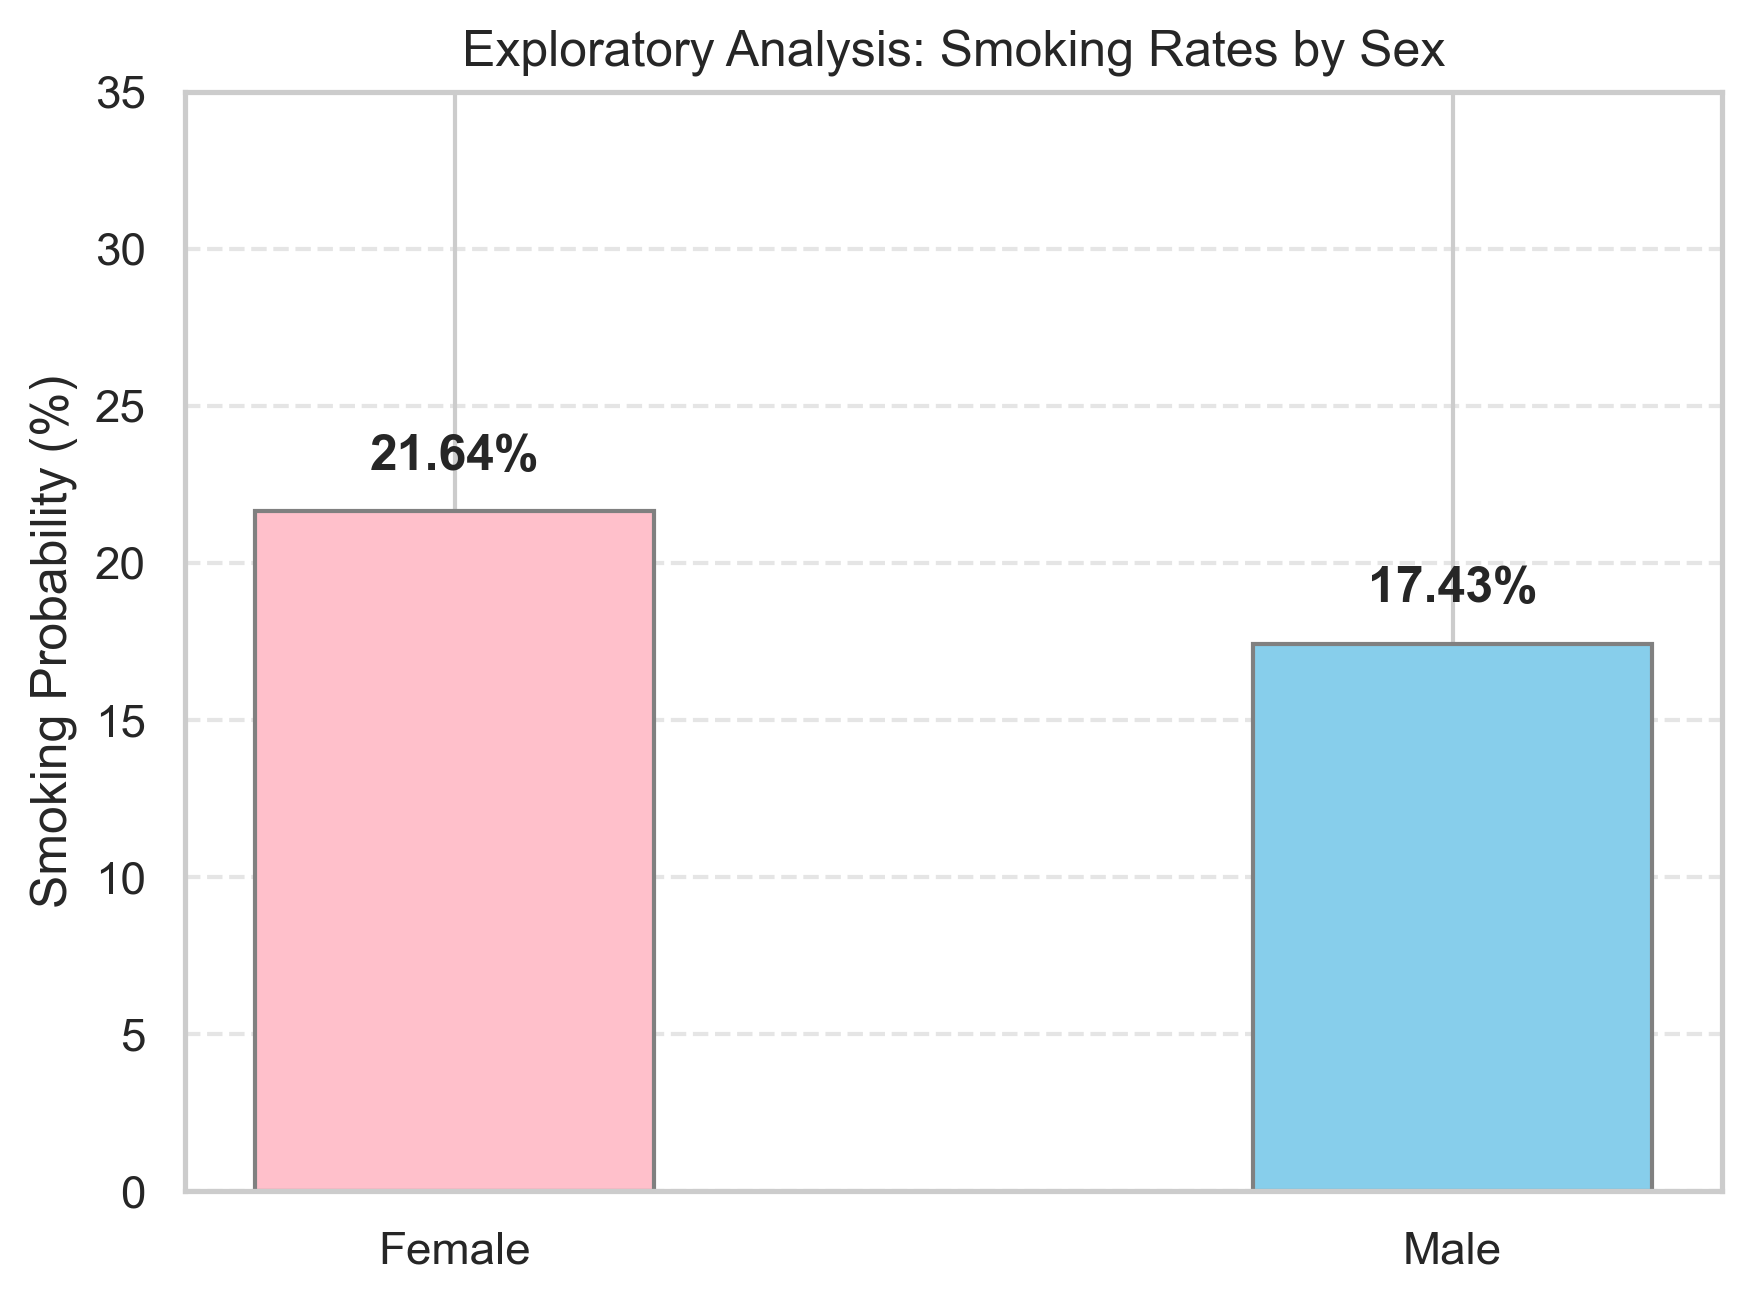

,Sex Group,Sample Size (n),Smoking Rate
0,Female,6502,21.64%
1,Male,6661,17.43%


In [103]:
df_sex = df_main[df_main['Sex'].isin([1, 2])].copy()
df_sex['Sex_recoded'] = df_sex['Sex'].replace({1.0: 1, 2.0: 0})

sex_summary = df_sex.groupby('Sex_recoded')['Smoke_recoded'].agg(['count', 'mean']).reset_index()
sex_summary['Sex_recoded'] = sex_summary['Sex_recoded'].map({0: 'Female', 1: 'Male'})
sex_summary.columns = ['Sex Group', 'Sample Size (n)', 'Smoking Rate']

os.makedirs('../outputs/tables/', exist_ok=True)
sex_summary.to_csv('../outputs/tables/sex_summary.csv', index=False)

plt.figure(figsize=(6, 4.5), dpi=300)
risk_female = df_sex[df_sex['Sex_recoded'] == 0]['Smoke_recoded'].mean()
risk_male = df_sex[df_sex['Sex_recoded'] == 1]['Smoke_recoded'].mean()
bars = plt.bar(['Female', 'Male'], [risk_female * 100, risk_male * 100], color=['pink', 'skyblue'], width=0.4, edgecolor='grey')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.ylabel('Smoking Probability (%)')
plt.title('Exploratory Analysis: Smoking Rates by Sex')
plt.ylim(0, 35)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

os.makedirs('../outputs/figures/', exist_ok=True)
plt.savefig('../outputs/figures/sex_exploration_bar.png', dpi=300, bbox_inches='tight')
plt.show()

sex_summary['Smoking Rate'] = sex_summary['Smoking Rate'].map(lambda x: f"{x*100:.2f}%")
display(sex_summary)

### Interpretation of Sex Exploratory Analysis
As an exploratory extension, we analyzed smoking prevalence by biological sex. Male students exhibited a higher smoking rate than female students in this sample. This exploratory analysis suggests that while sadness is our primary focus, sex may represent another contributing vector to consider in future modeling.

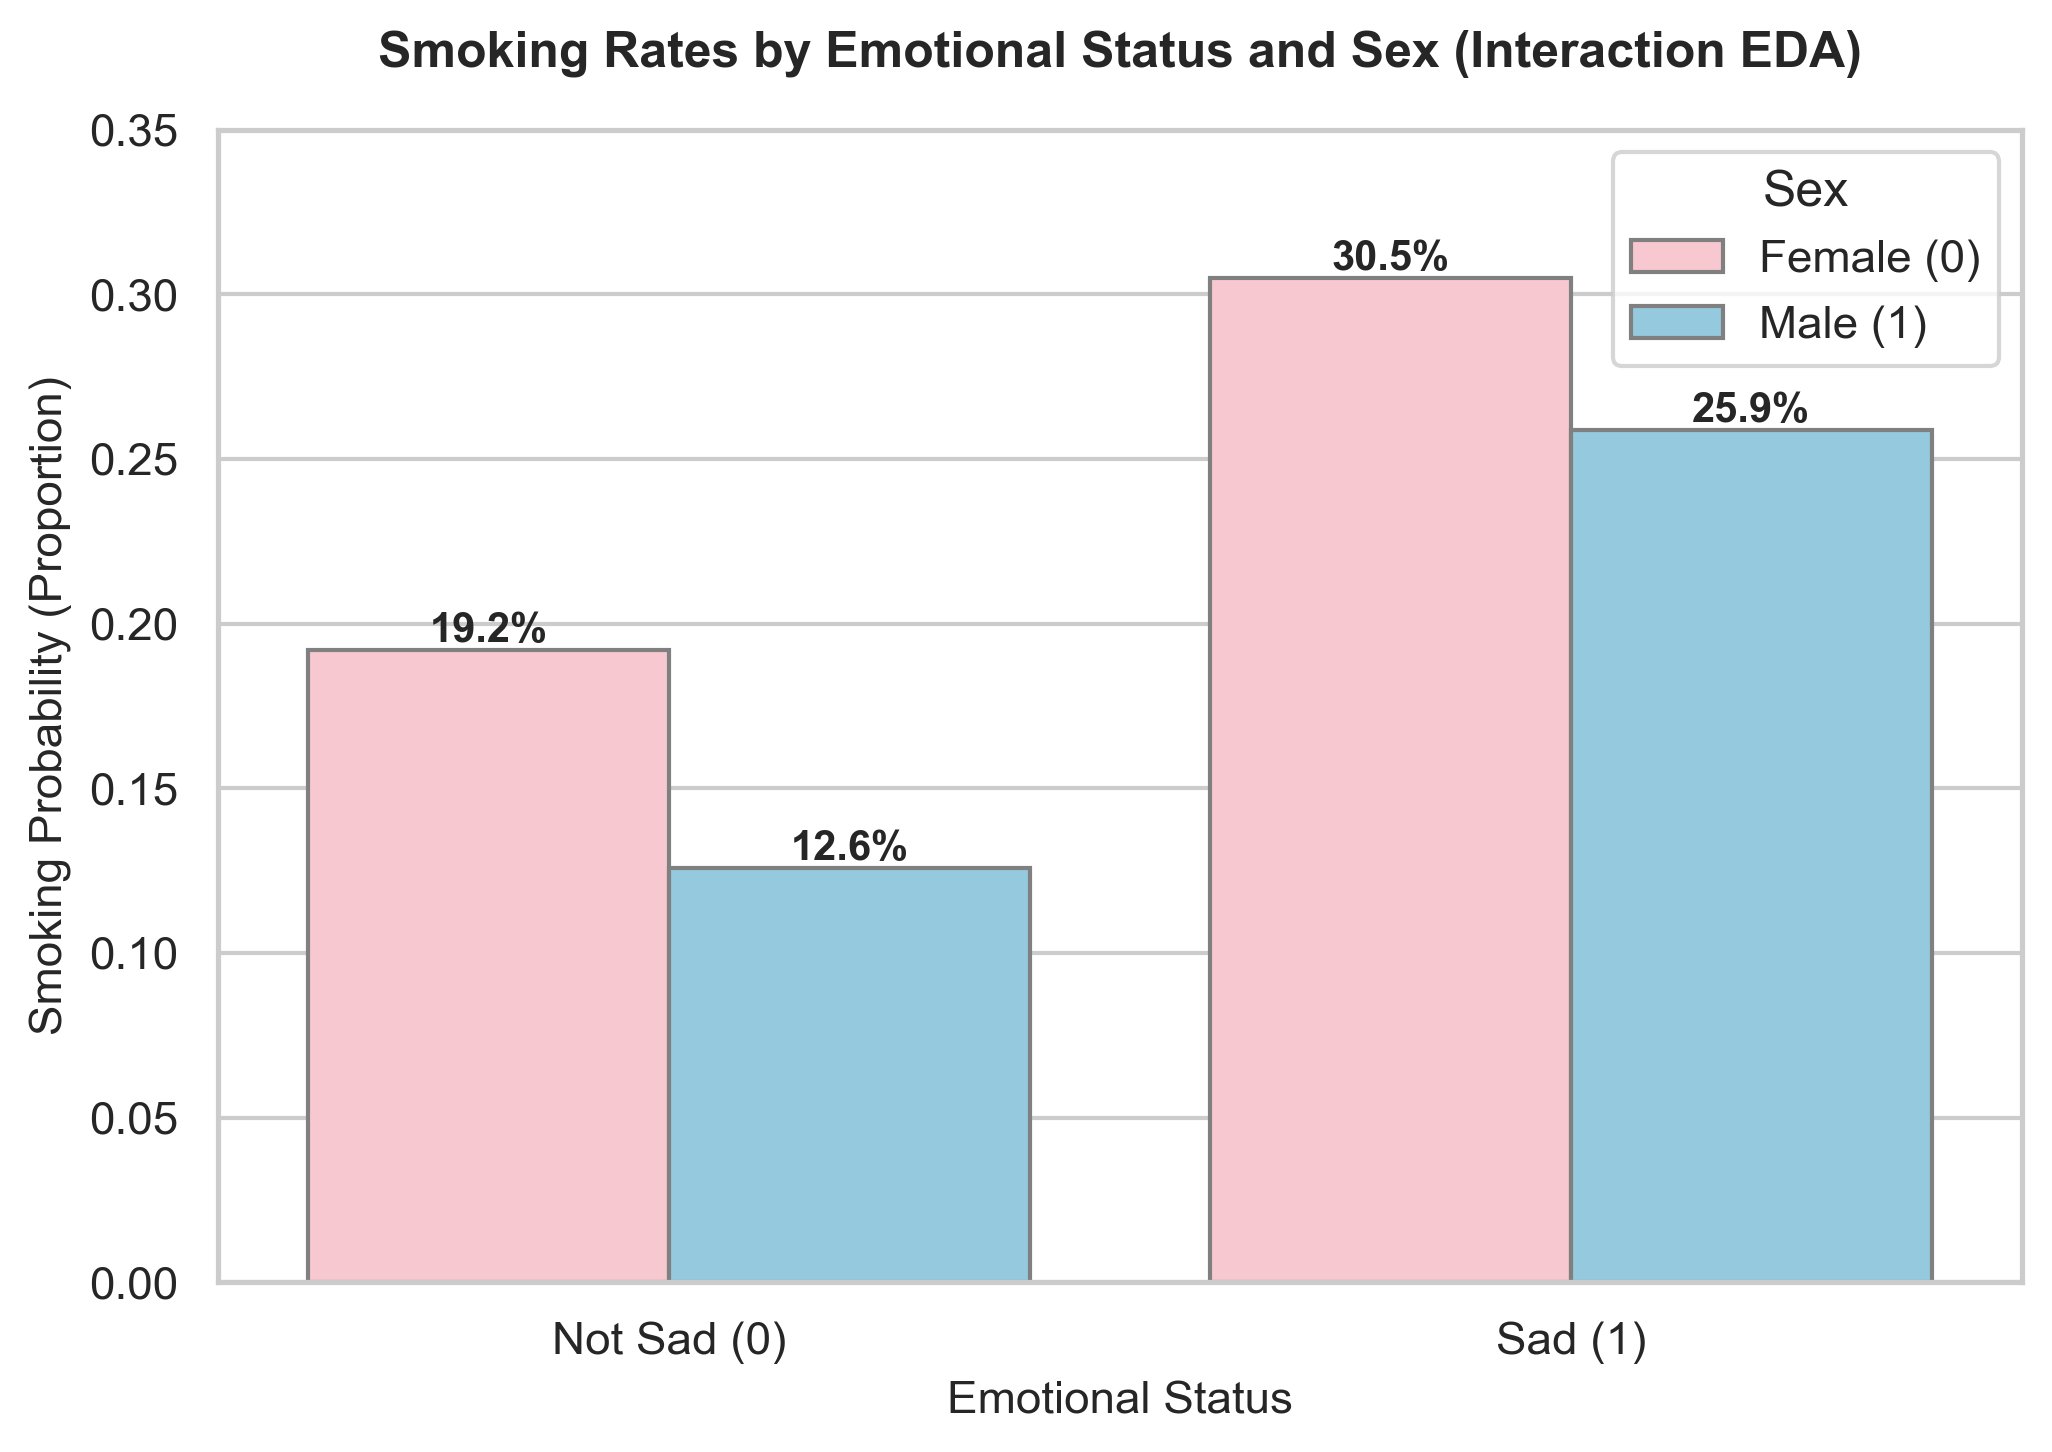

,Sex,Emotional Status,Sample Size (n),Smoking Rate
0,Female,Not Sad,5088,19.18%
1,Female,Sad,1414,30.48%
2,Male,Not Sad,4226,12.57%
3,Male,Sad,2435,25.87%


In [104]:
interaction_summary = df_sex.groupby(['Sex_recoded', 'Sad_recoded'])['Smoke_recoded'].agg(['count', 'mean']).reset_index()
interaction_summary['Sex_recoded'] = interaction_summary['Sex_recoded'].map({0: 'Female', 1: 'Male'})
interaction_summary['Sad_recoded'] = interaction_summary['Sad_recoded'].map({0: 'Not Sad', 1: 'Sad'})
interaction_summary.columns = ['Sex', 'Emotional Status', 'Sample Size (n)', 'Smoking Rate']

os.makedirs('../outputs/tables/', exist_ok=True)
interaction_summary.to_csv('../outputs/tables/interaction_summary.csv', index=False)

plt.figure(figsize=(7, 5), dpi=300)
ax = sns.barplot(x='Sad_recoded', y='Smoke_recoded', hue='Sex_recoded', data=df_sex, 
                 palette=['pink', 'skyblue'], errorbar=None, edgecolor='grey')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height*100:.1f}%', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xticks([0, 1], ['Not Sad (0)', 'Sad (1)'])
plt.ylabel('Smoking Probability (Proportion)', fontsize=11)
plt.xlabel('Emotional Status', fontsize=11)
plt.title('Smoking Rates by Emotional Status and Sex (Interaction EDA)', fontsize=12, fontweight='bold', pad=15)
plt.legend(title='Sex', labels=['Female (0)', 'Male (1)'])
plt.ylim(0, 0.35)
plt.tight_layout()

os.makedirs('../outputs/figures/', exist_ok=True)
plt.savefig('../outputs/figures/interaction_sex_sad_bar.png', dpi=300, bbox_inches='tight')
plt.show()

interaction_summary['Smoking Rate'] = interaction_summary['Smoking Rate'].map(lambda x: f"{x*100:.2f}%")
display(interaction_summary)

### Interpretation of Sex × Sadness Interaction EDA
The interaction analysis shows that smoking prevalence increases from the "Not Sad" group to the "Sad" group for both male and female students. 

This pattern suggests that the positive association between sadness and smoking is observed across both genders. However, further analysis using a multiple regression model would be needed to formally evaluate the independent contribution of each factor.

# 03 Linear Probability Model Analysis

## Hypothesis
* **Null Hypothesis ($H_0$):** $\beta_1 = 0$  
  There is no association between sadness and smoking probability (the slope coefficient is zero).
* **Alternative Hypothesis ($H_1$):** $\beta_1 \neq 0$  
  There is an association between sadness and smoking probability (the slope coefficient is not zero).

## Linear Probability Model Setup
* **Method:** Ordinary Least Squares (OLS) Regression / Linear Probability Model (LPM)
* **Dependent Variable (Y):** Smoke_recoded (Current Cigarette Use)
* **Independent Variable (X):** Sad_recoded (Sad or Hopeless Feeling)
* **Model Equation:** $$Smoke\_recoded = \beta_0 + \beta_1 \times Sad\_recoded$$
* **Significance Level (Alpha):** 0.05

In [105]:
import statsmodels.formula.api as smf

lm_model = smf.ols("Smoke_recoded ~ Sad_recoded", data=df_main).fit()

print("--- Full OLS Regression Summary (For Complete Workflow) ---")
print(lm_model.summary())

print("\n--- Polished Summary Table ---")
summary_data = {
    "Parameter": ["Intercept (β₀)", "Sad_recoded (β₁)"],
    "Estimate (coef)": [f"{lm_model.params['Intercept']:.4f}", f"{lm_model.params['Sad_recoded']:.4f}"],
    "p-value": [f"{lm_model.pvalues['Intercept']:.3e}", f"{lm_model.pvalues['Sad_recoded']:.3e}"],
    "95% Conf. Interval": [
        f"({lm_model.conf_int().loc['Intercept', 0]:.3f}, {lm_model.conf_int().loc['Intercept', 1]:.3f})",
        f"({lm_model.conf_int().loc['Sad_recoded', 0]:.3f}, {lm_model.conf_int().loc['Sad_recoded', 1]:.3f})"
    ]
}
reg_summary_df = pd.DataFrame(summary_data)

os.makedirs('../outputs/tables/', exist_ok=True)
reg_summary_df.to_csv('../outputs/tables/regression_summary.csv', index=False)

display(reg_summary_df)

--- Full OLS Regression Summary (For Complete Workflow) ---
                            OLS Regression Results                            
Dep. Variable:          Smoke_recoded   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     230.5
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.24e-51
Time:                        06:14:24   Log-Likelihood:                -6387.8
No. Observations:               13174   AIC:                         1.278e+04
Df Residuals:                   13172   BIC:                         1.279e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

,Parameter,Estimate (coef),p-value,95% Conf. Interval
0,Intercept (β₀),0.1618,0.000e+00,"(0.154, 0.170)"
1,Sad_recoded (β₁),0.1143,1.241e-51,"(0.100, 0.129)"


### Interpretation of Regression Results
The Ordinary Least Squares (OLS) regression analysis reveals a statistically significant relationship between sadness and smoking behavior. The intercept ($\beta_0$) is 0.1618, representing that students without sad feelings have a baseline smoking probability of 16.18%. The regression analysis confirms that students who reported sadness or hopelessness were associated with an 11.43 percentage-point higher smoking probability, strongly rejecting the null hypothesis.

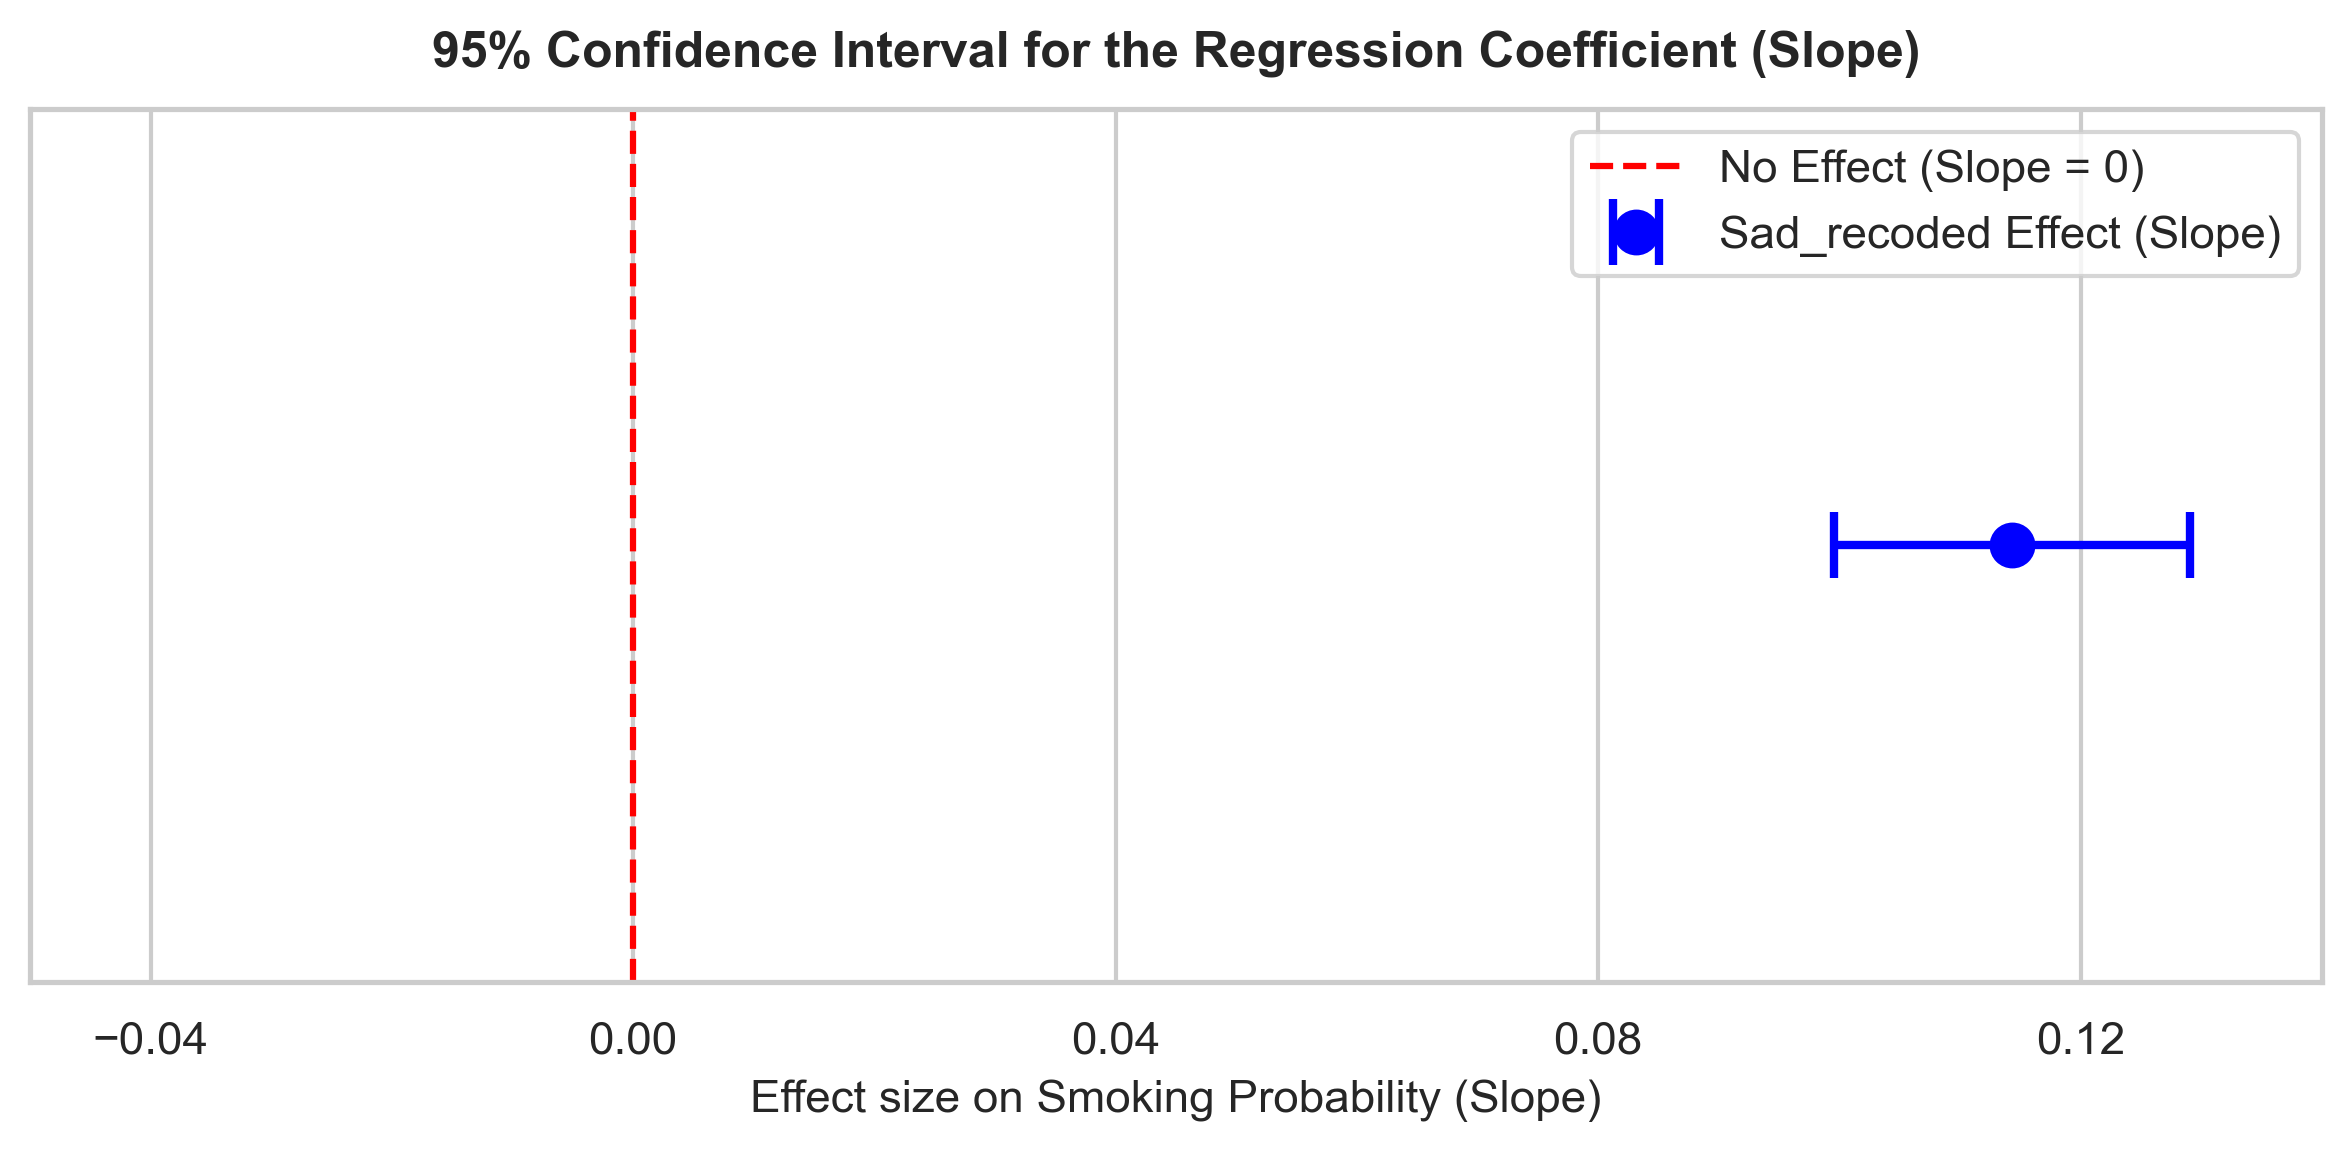

In [106]:
import matplotlib.pyplot as plt

conf_int = lm_model.conf_int().loc['Sad_recoded']
slope_estimate = lm_model.params['Sad_recoded']
ci_lower = conf_int[0]
ci_upper = conf_int[1]

plt.figure(figsize=(8, 4), dpi=300)
plt.axvline(x=0, color='red', linestyle='--', label='No Effect (Slope = 0)')
plt.errorbar(x=slope_estimate, y=0, 
             xerr=[[slope_estimate - ci_lower], [ci_upper - slope_estimate]], 
             fmt='o', color='blue', markersize=10, capsize=8, capthick=2, elinewidth=2,
             label='Sad_recoded Effect (Slope)')

plt.xlim(-0.05, 0.14)
plt.xticks([-0.04, 0.00, 0.04, 0.08, 0.12])
plt.yticks([])
plt.title('95% Confidence Interval for the Regression Coefficient (Slope)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Effect size on Smoking Probability (Slope)', fontsize=11)
plt.legend(loc='upper right')
plt.tight_layout()

os.makedirs('../outputs/figures/', exist_ok=True)
plt.savefig('../outputs/figures/regression_ci_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of Regression Coefficient Plot
The 95% confidence interval for the regression coefficient of Sad_recoded ranges from 0.100 to 0.129. Because this interval is entirely above zero and does not cross the red dashed line (Slope = 0), it visually demonstrates that the positive effect of emotional distress on smoking prevalence is statistically stable and highly significant.

### Statistical Note (Correlation vs. Causation)
Although a statistically significant association was observed, this study does not establish a causal relationship between sadness and smoking behavior. Because the data were collected at one point in time, other factors may also contribute to the observed relationship.

# 04 Final Conclusion

This study examined whether feelings of sadness or hopelessness are associated with current cigarette use among adolescents.

The analysis demonstrates that adolescent students experiencing sadness or hopelessness exhibit an 11.43 percentage-point higher smoking prevalence compared with those who do not report such feelings (27.61% compared with 16.18%). The smoking prevalence in the sad or hopeless group was approximately 1.71 times that of the non-sad group. The regression analysis confirms that this relationship is highly statistically significant ($p < 0.001$), and the 95% confidence interval does not include zero. 

Therefore, emotional well-being may represent an important public health factor related to adolescent smoking behavior.

### 📌 Limitations and Future Research
* **Single-Factor Model Focus:** This study focuses primarily on the univariate relationship between sadness and smoking behavior within the linear probability framework. 
* **Potential Confounding Factors:** Other variables such as sex, age, grade, alcohol use, peer influence, and family environment may also be associated with smoking behavior and were not formally controlled in our main regression analysis.
* **Future Recommendation:** While our exploratory interaction analysis confirmed that sadness is associated with higher smoking across both genders, future studies could incorporate sex, age, and other demographic variables into a multiple regression model to determine whether the observed association remains significant after adjusting for these factors.

In [107]:
import os

summary_target_dir = os.path.abspath(os.path.join('..', 'outputs', 'summary'))
references_target_dir = os.path.abspath(os.path.join('..', 'references'))

os.makedirs(summary_target_dir, exist_ok=True)
os.makedirs(references_target_dir, exist_ok=True)

summary_text = """# Final Individual Project: One-Page Research Summary

* Name: Lin, Chia-Hsin
* Student ID: 111370235
* Topic: Adolescent Smoking and Emotional Health Analysis

### 1. Introduction & Motivation
Adolescent substance use poses severe long-term public health challenges. This study utilizes data from the 2007 Youth Risk Behavior Surveillance System (YRBSS) to evaluate whether chronic feelings of sadness or hopelessness independently serve as a statistically significant predictor of current cigarette smoking behavior among teenagers.

### 2. Methodology
The final sample contains 13,174 valid observations. Categorical variables were recoded into binary formats: Sad_recoded (1=Sad, 0=Not Sad) and Smoke_recoded (1=Current Smoker, 0=Non-Smoker). A Linear Probability Model (Ordinary Least Squares regression) was executed to formally test the null hypothesis at an alpha level of 0.05.

### 3. Empirical Results
* Descriptive and Risk Profile: The baseline smoking rate for the non-distressed cohort is 16.18%, whereas the distressed cohort exhibits a smoking prevalence of 27.61%. The calculated relative risk indicates that emotionally distressed adolescents are approximately 1.71 times more likely to smoke.
* Exploratory Demographic Extension: Stratified interaction analysis indicates that smoking rates increase consistently when transitioning from "Not Sad" to "Sad" within both gender cohorts, suggesting that the emotional health risk vector operates universally across genders.
* Regression Inference: The regression model establishes a highly significant statistical association (p < 0.001). The model yields an estimated intercept of 0.1618 and a slope coefficient of 0.1143. Experiencing prolonged sadness is associated with an 11.43 percentage-point higher probability of current smoking. The 95% confidence interval for the slope ranges from 0.100 to 0.129, comfortably excluding zero.

### 4. Discussion & Conclusion
The statistical evidence strongly rejects the null hypothesis, demonstrating that emotional distress is a powerful, robust predictor of youth tobacco use. Future public health research should incorporate demographic control variables into a multiple regression framework to evaluate whether the independent impact of emotional health remains significant after adjusting for these factors.
"""

references_text = """# Project References

1. Centers for Disease Control and Prevention (CDC). (2007). Youth Risk Behavior Surveillance System (YRBSS). Data available from https://www.cdc.gov/yrbs/index.html
2. Linear Probability Model and Ordinary Least Squares Estimation for Binary Outcomes in Social Sciences.
"""

with open(os.path.join(summary_target_dir, 'summary.txt'), 'w', encoding='utf-8') as f:
    f.write(summary_text)

with open(os.path.join(references_target_dir, 'references.txt'), 'w', encoding='utf-8') as f:
    f.write(references_text)

print(f"Summary file successfully generated at: {os.path.join(summary_target_dir, 'summary.txt')}")
print(f"References file successfully generated at: {os.path.join(references_target_dir, 'references.txt')}")

Summary file successfully generated at: C:\Users\88695\OneDrive\桌面\final-project\outputs\summary\summary.txt
References file successfully generated at: C:\Users\88695\OneDrive\桌面\final-project\references\references.txt
